## Research Question
Can machine learning models effectively detect and assign risk levels to “shadow API” calls?

## Problem Statement
Organizations often struggle to maintain visibility over all their API endpoints, leading to increased security vulnerabilities and a broader attack surface. While many companies utilize API Gateways to manage request-response interactions, rogue or undocumented Apis, commonly known as shadow APIs, pose serious security, compliance, and operational threats. Traditional discovery methods are largely manual, inefficient, and error-prone, making it difficult to proactively manage these risks.

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

### Load Dataset

In [2]:
df = pd.read_csv("supervised_dataset.csv")
df.head()

,Unnamed: 0,_id,inter_api_access_duration(sec),api_access_uniqueness,sequence_length(count),vsession_duration(min),ip_type,num_sessions,num_users,num_unique_apis,source,classification
0,0,1f2c32d8-2d6e-3b68-bc46-789469f2b71e,0.000812,0.004066,85.643243,5405,default,1460.0,1295.0,451.0,E,normal
1,1,4c486414-d4f5-33f6-b485-24a8ed2925e8,0.000063,0.002211,16.166805,519,default,9299.0,8447.0,302.0,E,normal
2,2,7e5838fc-bce1-371f-a3ac-d8a0b2a05d9a,0.004481,0.015324,99.573276,6211,default,255.0,232.0,354.0,E,normal
3,3,82661ecd-d87f-3dff-855e-378f7cb6d912,0.017837,0.014974,69.792793,8292,default,195.0,111.0,116.0,E,normal
4,4,d62d56ea-775e-328c-8b08-db7ad7f834e5,0.000797,0.006056,14.952756,182,default,272.0,254.0,23.0,E,normal


In [3]:
print("Shape of dataset:", df.shape)
df.info()

Shape of dataset: (1699, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1699 entries, 0 to 1698
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Unnamed: 0                      1699 non-null   int64  
 1   _id                             1699 non-null   object 
 2   inter_api_access_duration(sec)  1695 non-null   float64
 3   api_access_uniqueness           1695 non-null   float64
 4   sequence_length(count)          1699 non-null   float64
 5   vsession_duration(min)          1699 non-null   int64  
 6   ip_type                         1699 non-null   object 
 7   num_sessions                    1699 non-null   float64
 8   num_users                       1699 non-null   float64
 9   num_unique_apis                 1699 non-null   float64
 10  source                          1699 non-null   object 
 11  classification                  1699 non-null   object 
dtypes: fl

### Data Cleaning

In [4]:
df.isnull().sum()

Unnamed: 0                        0
_id                               0
inter_api_access_duration(sec)    4
api_access_uniqueness             4
sequence_length(count)            0
vsession_duration(min)            0
ip_type                           0
num_sessions                      0
num_users                         0
num_unique_apis                   0
source                            0
classification                    0
dtype: int64

In [5]:
# Fill Missing values
df['inter_api_access_duration(sec)'] = df['inter_api_access_duration(sec)'].fillna(
    df['inter_api_access_duration(sec)'].mean())
df['api_access_uniqueness'] = df['api_access_uniqueness'].fillna(
    df['api_access_uniqueness'].mean())
df.isnull().sum()

Unnamed: 0                        0
_id                               0
inter_api_access_duration(sec)    0
api_access_uniqueness             0
sequence_length(count)            0
vsession_duration(min)            0
ip_type                           0
num_sessions                      0
num_users                         0
num_unique_apis                   0
source                            0
classification                    0
dtype: int64

In [6]:
# Drop Unnnecessary Columns
df = df.drop(columns=['Unnamed: 0', '_id'], errors='ignore')

### Convert Target Variable

In [7]:
df['classification'] = df['classification'].map({
    'normal': 0,
    'outlier': 1
})

### Encode Categorical Columns

In [8]:
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    df[col] = df[col].astype('category').cat.codes

### Define Features and Target

In [9]:
X = df.drop('classification', axis=1)
y = df['classification']

### Train-Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,test_size=0.2,random_state=42,
)
print("Training Size:", X_train.shape)
print("Testing Size:", X_test.shape)

Training Size: (1359, 9)
Testing Size: (340, 9)


### Feature Scaling

In [11]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Logistic regression model

In [12]:
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train)
y_pred_log = log_model.predict(X_test_scaled)

In [13]:
print("Logistic Regression Accuracy: ", accuracy_score(y_test, y_pred_log))
print("\nClassification Report:\n", classification_report(y_test, y_pred_log))


Logistic Regression Accuracy:  0.9970588235294118

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       229
           1       1.00      0.99      1.00       111

    accuracy                           1.00       340
   macro avg       1.00      1.00      1.00       340
weighted avg       1.00      1.00      1.00       340



- The Logistic Regression model achieved 99.7% accuracy in classifying API calls.

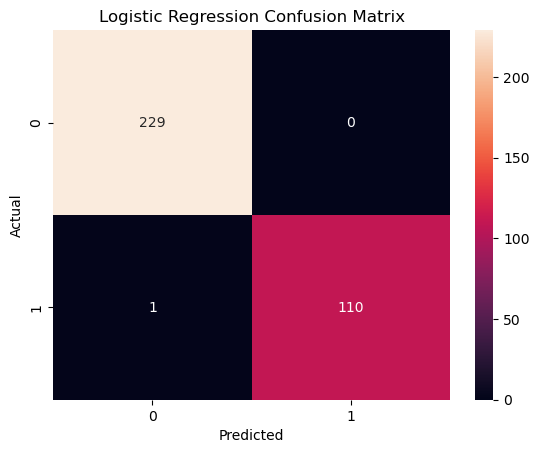

In [14]:
cm = confusion_matrix(y_test, y_pred_log)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()


The confusion matrix shows that 229 risky API calls were correctly classified.

110 normal API calls were correctly classified, while only 1 normal API call was misclassified.

### Random Forest Model

In [15]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

In [16]:
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       229
           1       1.00      1.00      1.00       111

    accuracy                           1.00       340
   macro avg       1.00      1.00      1.00       340
weighted avg       1.00      1.00      1.00       340



The Random Forest model achieved 100% accuracy.


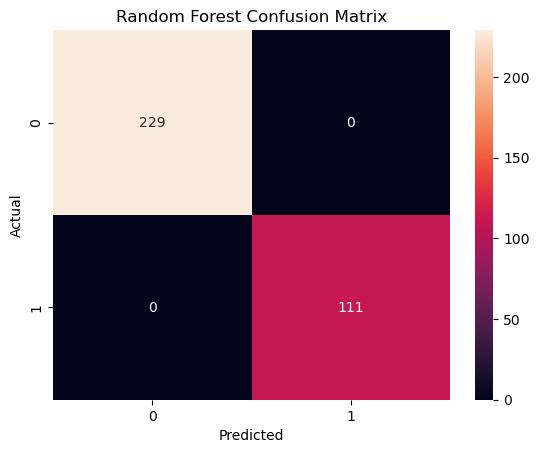

In [17]:
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()



The confusion matrix shows that 229 risky API calls and 111 normal API calls were correctly classified.

There were no incorrect predictions in the Random Forest model.